In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/refs/heads/main/googleplaystore.csv')

In [3]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 2.2 MB


In [5]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [6]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

#### Insights and observation
Data Cleaning
The dataset has missing values


In [7]:
df['Reviews'].unique()

<ArrowStringArray>
[   '159',    '967',  '87510', '215644',    '167',    '178',  '36815',
  '13791',    '121',  '13880',
 ...
   '2036',  '56496', '376223',    '785',   '5775',    '885',  '88486',
    '603',   '1195', '398307']
Length: 6002, dtype: str

In [8]:
# df['Reviews'].astype(int) -> throws error

In [9]:
df['Reviews'].str.isnumeric().sum()

np.int64(10840)

In [10]:
df.loc[~df["Reviews"].str.isnumeric(), "Reviews"]

10472    3.0M
Name: Reviews, dtype: str

In [11]:
df[~df["Reviews"].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [12]:
df_copy = df.copy()

In [13]:
df_copy = df_copy.drop(df_copy.index[10472])

In [14]:
df_copy[~df_copy['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [15]:
## convet revies datatype to int

df_copy['Reviews'].astype(int)

0           159
1           967
2         87510
3        215644
4           967
          ...  
10836        38
10837         4
10838         3
10839       114
10840    398307
Name: Reviews, Length: 10840, dtype: int64

In [16]:

df_copy["Size"].unique()

<ArrowStringArray>
[  '19M',   '14M',  '8.7M',   '25M',  '2.8M',  '5.6M',   '29M',   '33M',
  '3.1M',   '28M',
 ...
  '467k',  '157k',   '44k',  '676k',   '67k',  '552k',  '885k', '1020k',
  '582k',  '619k']
Length: 461, dtype: str

In [17]:
df_copy['Size'].isnull().sum()

np.int64(0)

In [18]:
df_copy['Size'] = df_copy['Size'].str.replace('M','000') # converting M to K units 19M -> 19000K


In [19]:
df_copy['Size'] = df_copy['Size'].str.replace('k','')
df_copy['Size'] = df_copy['Size'].replace('Varies with device',np.nan)

In [20]:
df_copy['Size'] = df_copy['Size'].astype(float)

In [21]:
df_copy['Installs'].unique()

<ArrowStringArray>
[       '10,000+',       '500,000+',     '5,000,000+',    '50,000,000+',
       '100,000+',        '50,000+',     '1,000,000+',    '10,000,000+',
         '5,000+',   '100,000,000+', '1,000,000,000+',         '1,000+',
   '500,000,000+',            '50+',           '100+',           '500+',
            '10+',             '1+',             '5+',             '0+',
              '0']
Length: 21, dtype: str

In [22]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  str    
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  str    
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(2), str(11)
memory usage: 2.2 MB


In [23]:
df_copy['Installs'] = df_copy['Installs'].str.replace('+','')
df_copy['Installs'] = df_copy['Installs'].str.replace(',','')

In [24]:
df_copy['Install'] = df_copy['Installs'].astype(int)

In [25]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  str    
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  str    
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
 13  Install         10840 non-null  int64  
dtypes: float64(2), int64(1), str(11)
memory usage: 2.3 MB


In [26]:
df_copy['Price'].unique()

<ArrowStringArray>
[      '0',   '$4.99',   '$3.99',   '$6.99',   '$1.49',   '$2.99',   '$7.99',
   '$5.99',   '$3.49',   '$1.99',   '$9.99',   '$7.49',   '$0.99',   '$9.00',
   '$5.49',  '$10.00',  '$24.99',  '$11.99',  '$79.99',  '$16.99',  '$14.99',
   '$1.00',  '$29.99',  '$12.99',   '$2.49',  '$10.99',   '$1.50',  '$19.99',
  '$15.99',  '$33.99',  '$74.99',  '$39.99',   '$3.95',   '$4.49',   '$1.70',
   '$8.99',   '$2.00',   '$3.88',  '$25.99', '$399.99',  '$17.99', '$400.00',
   '$3.02',   '$1.76',   '$4.84',   '$4.77',   '$1.61',   '$2.50',   '$1.59',
   '$6.49',   '$1.29',   '$5.00',  '$13.99', '$299.99', '$379.99',  '$37.99',
  '$18.99', '$389.99',  '$19.90',   '$8.49',   '$1.75',  '$14.00',   '$4.85',
  '$46.99', '$109.99', '$154.99',   '$3.08',   '$2.59',   '$4.80',   '$1.96',
  '$19.40',   '$3.90',   '$4.59',  '$15.46',   '$3.04',   '$4.29',   '$2.60',
   '$3.28',   '$4.60',  '$28.99',   '$2.95',   '$2.90',   '$1.97', '$200.00',
  '$89.99',   '$2.56',  '$30.99',   '$3.61', 

In [27]:
df_copy['Price']=df_copy['Price'].str.replace('$','')

In [28]:
df_copy['Price'] = df_copy['Price'].astype(float)

In [29]:
df_copy['Content Rating'].unique()

<ArrowStringArray>
['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+', 'Adults only 18+',
 'Unrated']
Length: 6, dtype: str

In [30]:
df_copy['Last Updated'].unique()

<ArrowStringArray>
[   'January 7, 2018',   'January 15, 2018',     'August 1, 2018',
       'June 8, 2018',      'June 20, 2018',     'March 26, 2017',
     'April 26, 2018',      'June 14, 2018', 'September 20, 2017',
       'July 3, 2018',
 ...
  'November 23, 2015',      'June 17, 2012',  'February 27, 2015',
  'December 18, 2013',   'February 6, 2012',  'November 25, 2014',
       'May 19, 2016',   'January 20, 2014',  'February 16, 2014',
     'March 23, 2014']
Length: 1377, dtype: str

In [31]:
df_copy['Last Updated'] = pd.to_datetime(df_copy['Last Updated'])

In [32]:
df_copy['Day'] = df_copy['Last Updated'].dt.day
df_copy['Month'] = df_copy['Last Updated'].dt.month
df_copy['Year'] = df_copy['Last Updated'].dt.year

In [33]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  str           
 1   Category        10840 non-null  str           
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  str           
 4   Size            9145 non-null   float64       
 5   Installs        10840 non-null  str           
 6   Type            10839 non-null  str           
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  str           
 9   Genres          10840 non-null  str           
 10  Last Updated    10840 non-null  datetime64[us]
 11  Current Ver     10832 non-null  str           
 12  Android Ver     10838 non-null  str           
 13  Install         10840 non-null  int64         
 14  Day             10840 non-null  int32         
 15  Month           10

In [34]:
df_copy.drop('Last Updated',axis=1,inplace=True)

In [35]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  str    
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  str    
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Current Ver     10832 non-null  str    
 11  Android Ver     10838 non-null  str    
 12  Install         10840 non-null  int64  
 13  Day             10840 non-null  int32  
 14  Month           10840 non-null  int32  
 15  Year            10840 non-null  int32  
dtypes: float64(3), int32(3), int64(1), str(9)
memory usage: 2.1 MB


In [36]:
df_copy.to_csv('data/google_cleaned.csv')

#### EDA

In [37]:
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Install,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,1.0.0,4.0.3 and up,10000,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3 and up,500000,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,1.2.4,4.0.3 and up,5000000,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,Varies with device,4.2 and up,50000000,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,1.1,4.4 and up,100000,20,6,2018


In [38]:
df_copy[df_copy['App'].duplicated()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Install,Day,Month,Year
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,NaN,5000000,Free,0.0,Everyone,Business,Varies with device,4.0.3 and up,5000000,26,2,2018
236,Box,BUSINESS,4.2,159872,NaN,10000000,Free,0.0,Everyone,Business,Varies with device,Varies with device,10000000,31,7,2018
239,Google My Business,BUSINESS,4.4,70991,NaN,5000000,Free,0.0,Everyone,Business,2.19.0.204537701,4.4 and up,5000000,24,7,2018
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37000.0,10000000,Free,0.0,Everyone,Business,4.1.28165.0716,4.0 and up,10000000,20,7,2018
261,join.me - Simple Meetings,BUSINESS,4.0,6989,NaN,1000000,Free,0.0,Everyone,Business,4.3.0.508,4.4 and up,1000000,16,7,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10715,FarmersOnly Dating,DATING,3.0,1145,1.4,100000,Free,0.0,Mature 17+,Dating,2.2,4.0 and up,100000,25,2,2016
10720,Firefox Focus: The privacy browser,COMMUNICATION,4.4,36981,4.0,1000000,Free,0.0,Everyone,Communication,5.2,5.0 and up,1000000,6,7,2018
10730,FP Notebook,MEDICAL,4.5,410,60000.0,50000,Free,0.0,Everyone,Medical,2.1.0.372,4.4 and up,50000,24,3,2018
10753,Slickdeals: Coupons & Shopping,SHOPPING,4.5,33599,12000.0,1000000,Free,0.0,Everyone,Shopping,3.9,4.4 and up,1000000,30,7,2018


### The dataset has duplicated records - observation

In [39]:
df_copy.drop_duplicates(subset=['App'],keep='first', inplace=True)

In [40]:
df_copy.shape

(9659, 16)

In [41]:
categorical_feature = df_copy.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_feature = df_copy.select_dtypes(exclude=["object", "string"]).columns.tolist()
print('We have {} numerical features : {}'.format(len(numerical_feature),numerical_feature))
print('\nWe have {} categorical features: {}'.format(len(categorical_feature),categorical_feature))

We have 7 numerical features : ['Rating', 'Size', 'Price', 'Install', 'Day', 'Month', 'Year']

We have 9 categorical features: ['App', 'Category', 'Reviews', 'Installs', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


In [42]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 9659 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9659 non-null   str    
 1   Category        9659 non-null   str    
 2   Rating          8196 non-null   float64
 3   Reviews         9659 non-null   str    
 4   Size            8432 non-null   float64
 5   Installs        9659 non-null   str    
 6   Type            9658 non-null   str    
 7   Price           9659 non-null   float64
 8   Content Rating  9659 non-null   str    
 9   Genres          9659 non-null   str    
 10  Current Ver     9651 non-null   str    
 11  Android Ver     9657 non-null   str    
 12  Install         9659 non-null   int64  
 13  Day             9659 non-null   int32  
 14  Month           9659 non-null   int32  
 15  Year            9659 non-null   int32  
dtypes: float64(3), int32(3), int64(1), str(9)
memory usage: 1.9 MB


In [43]:
### Proportion of count of data on categorical columnns

for col in categorical_feature:
    print(df_copy[col].value_counts(normalize=True)*100)
    print('--------------------------------------------')

App
Photo Editor & Candy Camera & Grid & ScrapBook        0.010353
Coloring book moana                                   0.010353
U Launcher Lite – FREE Live Cool Themes, Hide Apps    0.010353
Sketch - Draw & Paint                                 0.010353
Pixel Draw - Number Art Coloring Book                 0.010353
                                                        ...   
Sya9a Maroc - FR                                      0.010353
Fr. Mike Schmitz Audio Teachings                      0.010353
Parkinson Exercices FR                                0.010353
The SCP Foundation DB fr nn5n                         0.010353
iHoroscope - 2018 Daily Horoscope & Astrology         0.010353
Name: proportion, Length: 9659, dtype: float64
--------------------------------------------
Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS                4.348276
MEDICAL                 4.089450
PERSONALIZATION         3.892743
PROD

/tmp/ipykernel_91618/1886719790.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df_copy[numerical_feature[i]],shade=True,color='r')
/tmp/ipykernel_91618/1886719790.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df_copy[numerical_feature[i]],shade=True,color='r')
/tmp/ipykernel_91618/1886719790.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df_copy[numerical_feature[i]],shade=True,color='r')
/tmp/ipykernel_91618/1886719790.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df_c

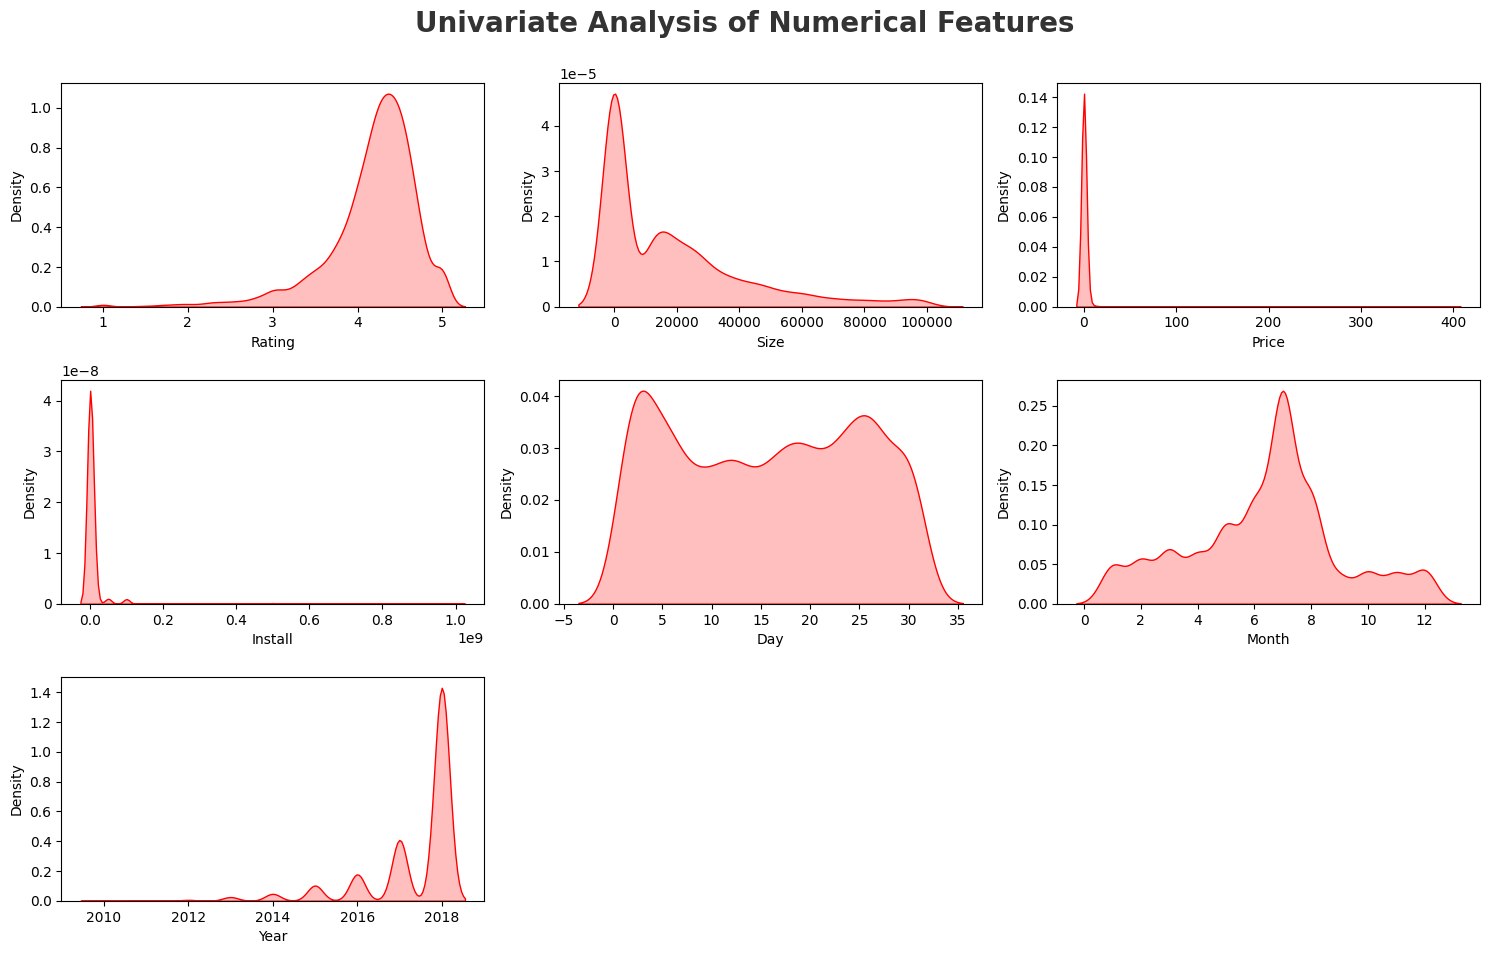

In [45]:
# Proportion and count data on numberical columns
plt.figure(figsize=(15,15))
plt.suptitle('Univariate Analysis of Numerical Features',fontsize=20,fontweight='bold',alpha=0.8,y=1)


for i in range(0,len(numerical_feature)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=df_copy[numerical_feature[i]],shade=True,color='r')
    plt.xlabel(numerical_feature[i])
    plt.tight_layout()

Observation.
Ratings cluster around ~4–4.5 with a left tail → most apps are rated fairly high.
Price is heavily right‑skewed → most apps are free or very low price, a few expensive outliers.
Install is extremely right‑skewed → a small number of apps dominate installs.
Size is right‑skewed → many apps are small, fewer large apps.
Year shows a sharp spike in recent years → most updates are from recent years.
Month/Day look fairly spread → updates happen across the calendar without a huge single‑day concentration.

/tmp/ipykernel_91618/2016742150.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_copy[category[i]],palette="Set2")
/tmp/ipykernel_91618/2016742150.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_copy[category[i]],palette="Set2")


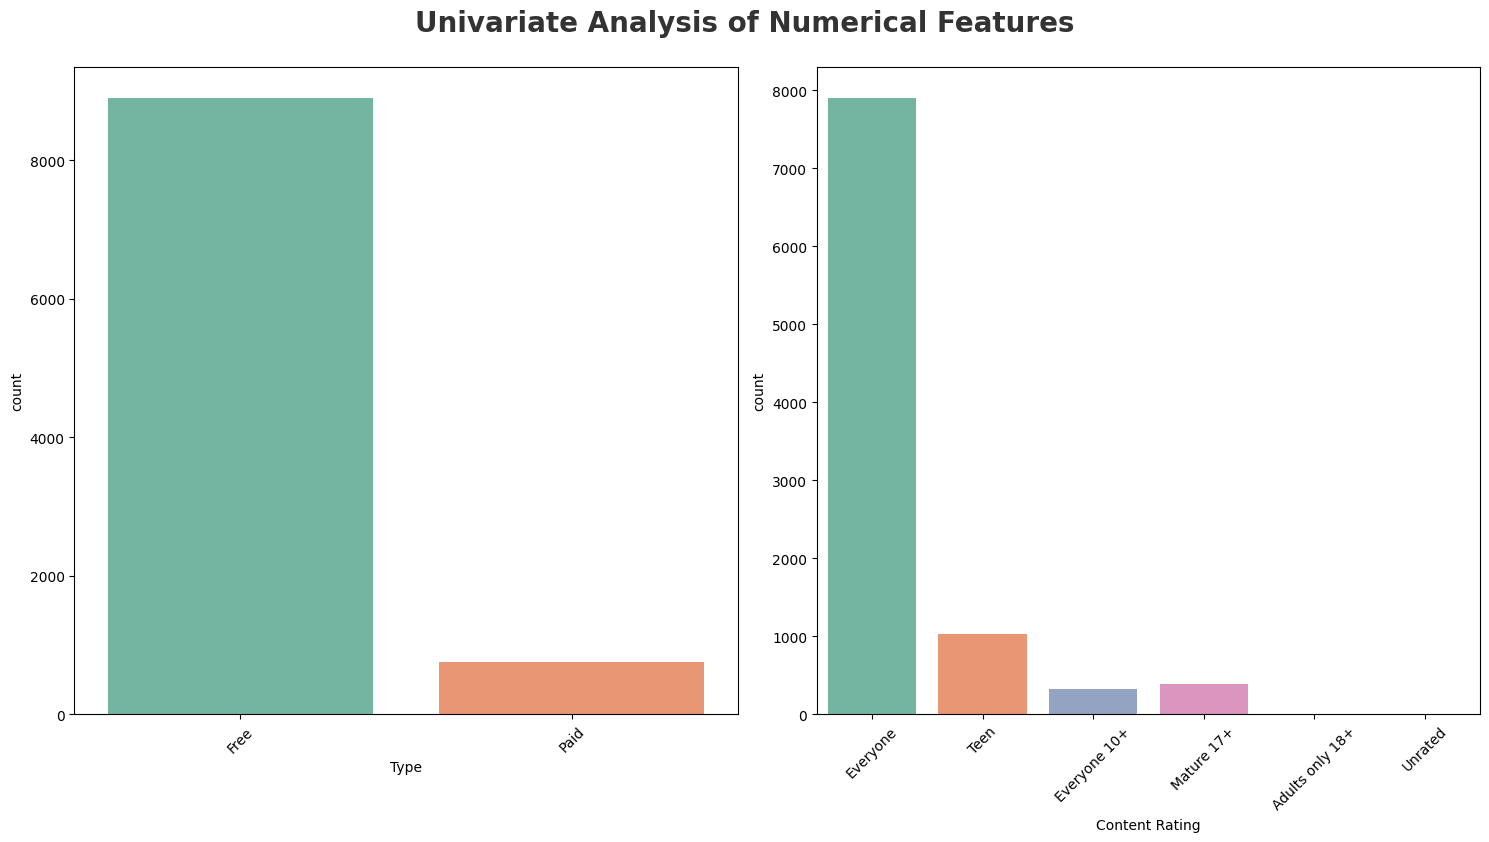

In [48]:
# Proportion and count data on categrical columns
plt.figure(figsize=(15,15))
plt.suptitle('Univariate Analysis of Numerical Features',fontsize=20,fontweight='bold',alpha=0.8,y=1)
category = ['Type','Content Rating']

for i in range(0,len(category)):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df_copy[category[i]],palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

### Which is the most populat app category ? 

In [50]:
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Install,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,1.0.0,4.0.3 and up,10000,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3 and up,500000,15,1,2018


<Axes: >

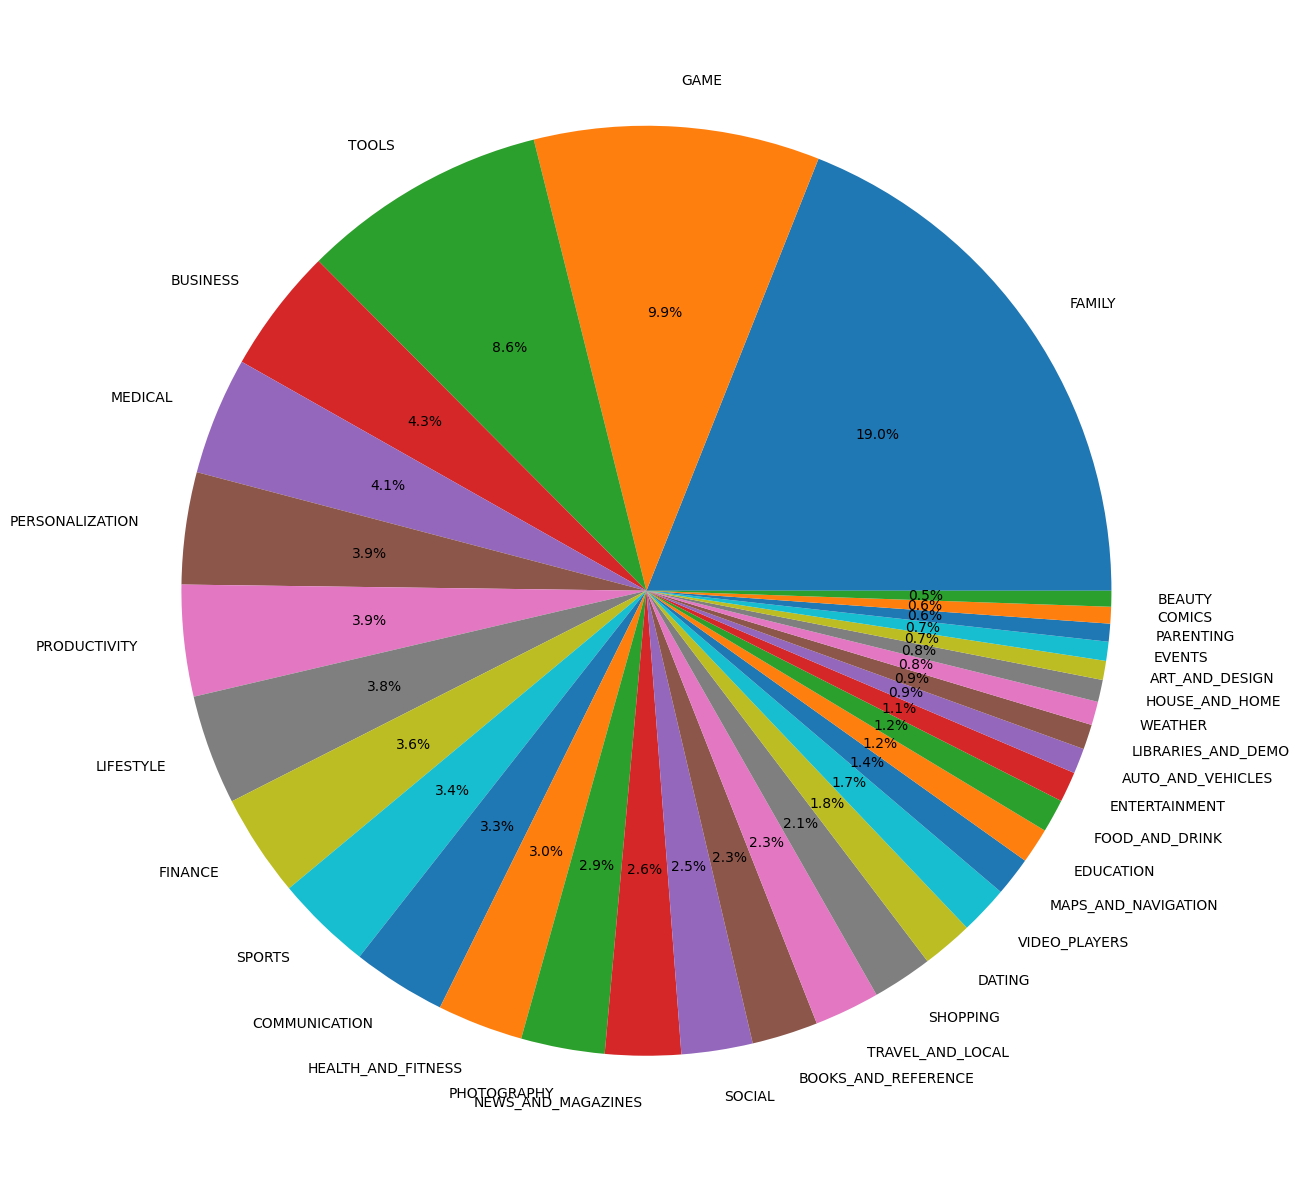

In [68]:
df_copy["Category"].value_counts().plot(
    kind="pie",
    figsize=(15, 16),
    autopct="%1.1f%%",
    ylabel=""
)

Observation: Family category has the most apps, followed by Game and Tools. This suggests that apps targeting families and games are particularly popular on the Google Play Store.

/tmp/ipykernel_91618/2138694988.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category", y="Count", data=category, palette="hls")


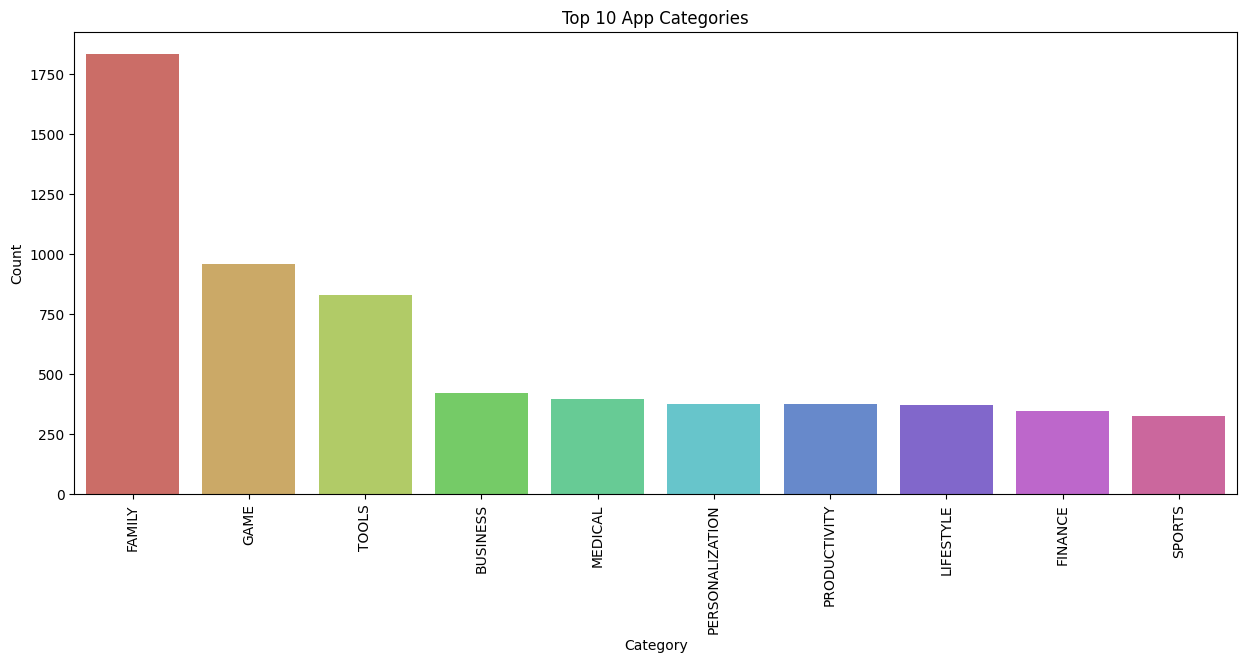

In [78]:
category = df_copy["Category"].value_counts().head(10).reset_index()
category.columns = ["Category", "Count"]

plt.figure(figsize=(15, 6))
sns.barplot(x="Category", y="Count", data=category, palette="hls")
plt.title("Top 10 App Categories")
plt.xticks(rotation=90)
plt.show()

It does two things:

1) **`value_counts().reset_index()`**  
   - `value_counts()` counts how many times each category appears.  
   - `reset_index()` turns that Series into a 2‑column DataFrame.

2) **`category.columns = ["Category", "Count"]`**  
   - renames the two columns for clarity:  
     - `Category` = the name of the category  
     - `Count` = how many rows in that category  

So you end up with a clean table you can plot with seaborn.

1. Which category has largest number of installations ? 
2. What are the Top 5 most installed apps ? 
3. How many appas are there on Google Play Store  which get 5 ratings ?
4. Which category has the highest average rating ?
5. Which category has the highest average price ?

In [80]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 9659 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9659 non-null   str    
 1   Category        9659 non-null   str    
 2   Rating          8196 non-null   float64
 3   Reviews         9659 non-null   str    
 4   Size            8432 non-null   float64
 5   Installs        9659 non-null   str    
 6   Type            9658 non-null   str    
 7   Price           9659 non-null   float64
 8   Content Rating  9659 non-null   str    
 9   Genres          9659 non-null   str    
 10  Current Ver     9651 non-null   str    
 11  Android Ver     9657 non-null   str    
 12  Install         9659 non-null   int64  
 13  Day             9659 non-null   int32  
 14  Month           9659 non-null   int32  
 15  Year            9659 non-null   int32  
dtypes: float64(3), int32(3), int64(1), str(9)
memory usage: 1.9 MB


#### List of top installed apps

In [92]:
high_installs = df_copy[['App','Install']].sort_values(by="Install",ascending=False).head(10)
high_installs.columns = ["App","Installs"]
high_installs

,App,Installs
3736,Google News,1000000000
2554,Google+,1000000000
1654,Subway Surfers,1000000000
152,Google Play Books,1000000000
3665,YouTube,1000000000
2545,Instagram,1000000000
3687,Google Play Movies & TV,1000000000
2808,Google Photos,1000000000
3127,Google Street View,1000000000
865,Google Play Games,1000000000


#### List of top installed categories.

/tmp/ipykernel_91618/354335289.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category", y="Install", data=high_installs, palette="hls")


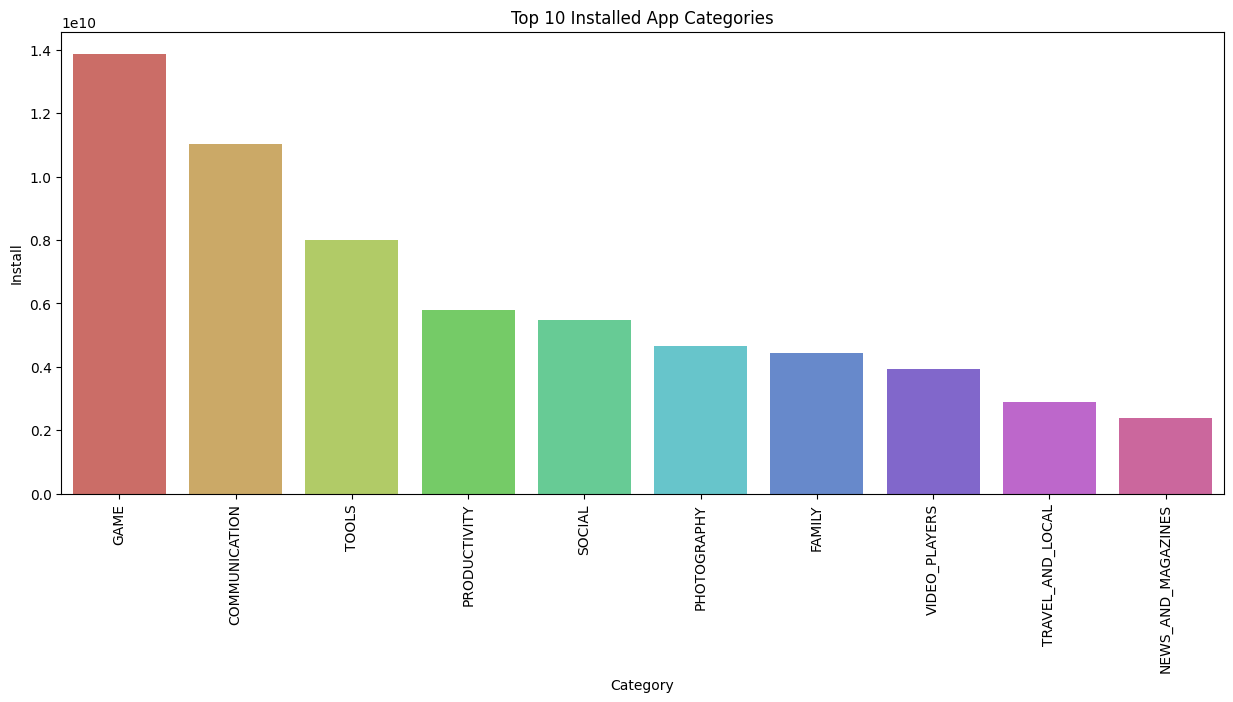

In [ ]:
high_installs = (
    df_copy.groupby("Category", as_index=False)["Install"].sum()
    .sort_values(by="Install", ascending=False) # type: ignore
    .head(10)
)
# Grouping the apps by categories and summing up the installs to display it.
plt.figure(figsize=(15, 6))
sns.barplot(x="Category", y="Install", data=high_installs, palette="hls")
plt.title("Top 10 Installed App Categories")
plt.xticks(rotation=90)
plt.show()

/tmp/ipykernel_91618/1842680712.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category",y="Rating",data=high_rating, palette="hls")


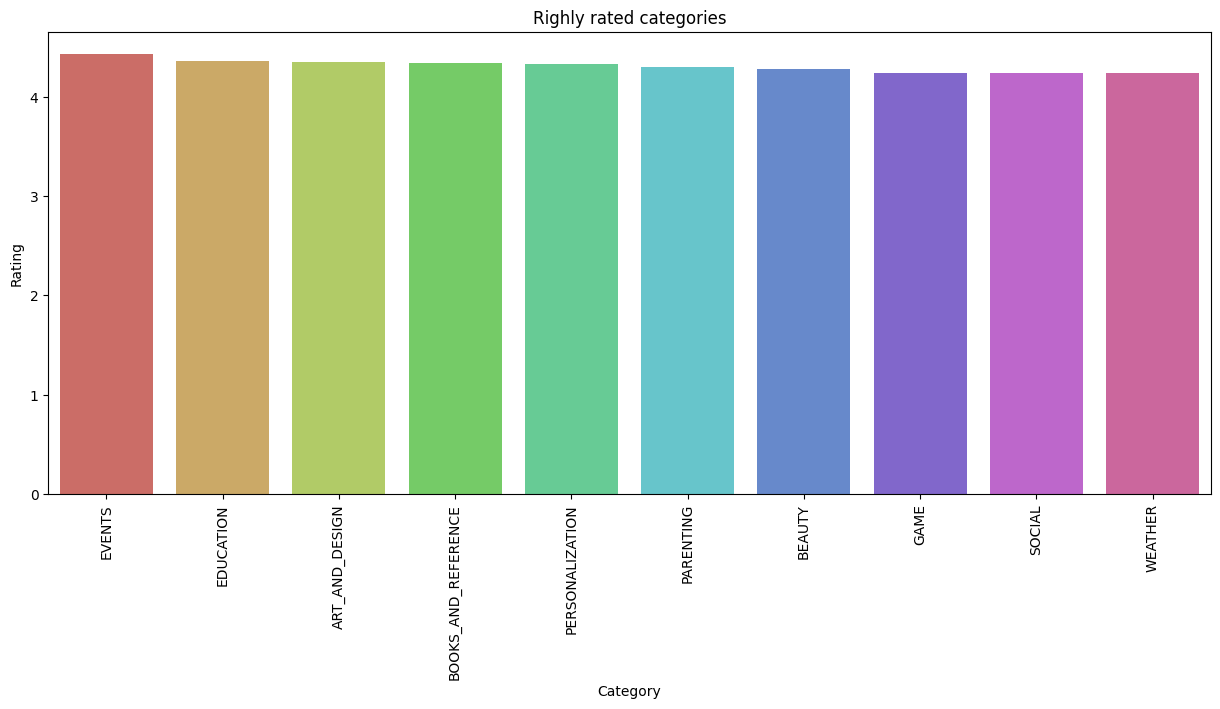

In [110]:
high_rating = (
    df_copy.groupby("Category", as_index=False)["Rating"].mean()
    .sort_values(by="Rating", ascending=False)
    .head(10)
) # type: ignore

plt.figure(figsize=(15,6))
sns.barplot(x="Category",y="Rating",data=high_rating, palette="hls")
plt.title("Righly rated categories")
plt.xticks(rotation=90)
plt.show()


/tmp/ipykernel_91618/2707276499.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category",y="Price",data=high_rating, palette="hls")


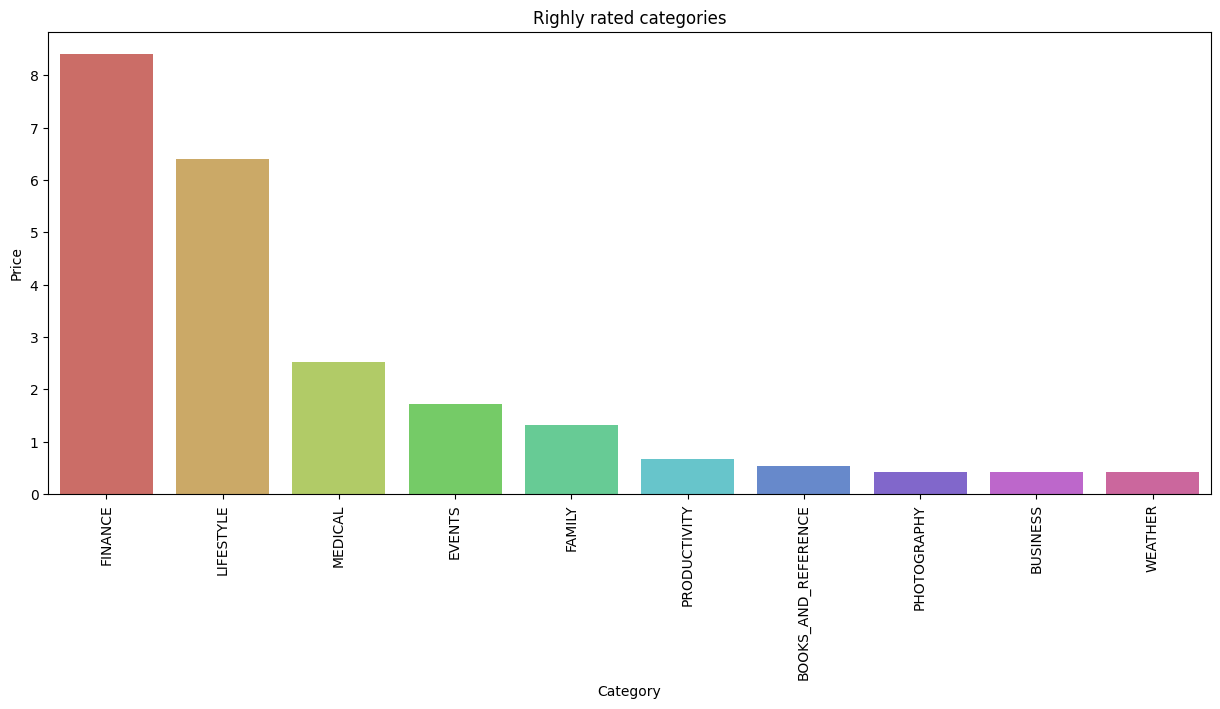

In [107]:
high_rating = (
    df_copy.groupby("Category", as_index=False)["Price"].mean()
    .sort_values(by="Price", ascending=False)
    .head(10)
) # type: ignore

plt.figure(figsize=(15,6))
sns.barplot(x="Category",y="Price",data=high_rating, palette="hls")
plt.title("Righly rated categories")
plt.xticks(rotation=90)
plt.show()